<a href="https://colab.research.google.com/github/nanditanair05-byte/unsupervised_learning_casestudy/blob/main/Unsupervised_learning_casestudy_Nandita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv("/content/drive/MyDrive/DSA/unsupervised learning/adult_dataset.csv")

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

Shape: (48842, 15)

Columns:
Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [7]:


df = df.replace("?", np.nan)

df.isnull().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


In [8]:
num_cols = ['age', 'fnlwgt', 'education-num',
            'capital-gain', 'capital-loss', 'hours-per-week']

cat_cols = ['workclass', 'education', 'marital-status',
            'occupation', 'relationship', 'race',
            'sex', 'native-country']

# Fill numerical missing values with median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


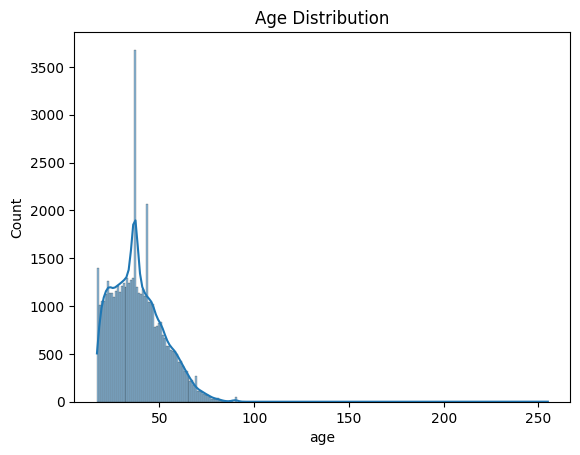

In [9]:
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

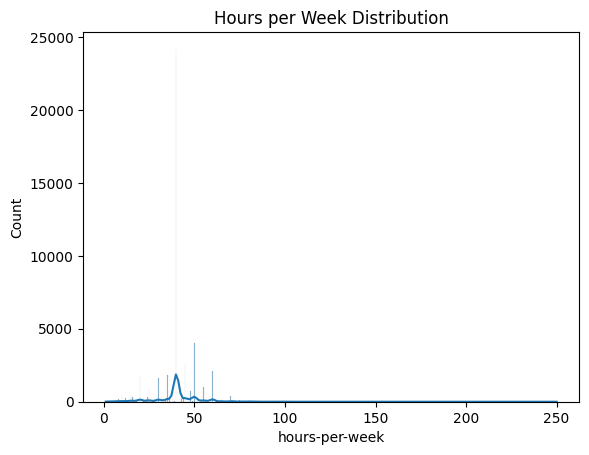

In [10]:
sns.histplot(df['hours-per-week'], kde=True)
plt.title("Hours per Week Distribution")
plt.show()

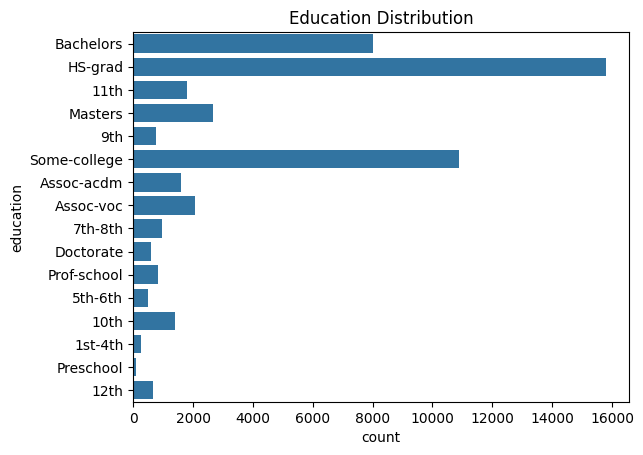

In [11]:
sns.countplot(data=df, y='education')
plt.title("Education Distribution")
plt.show()

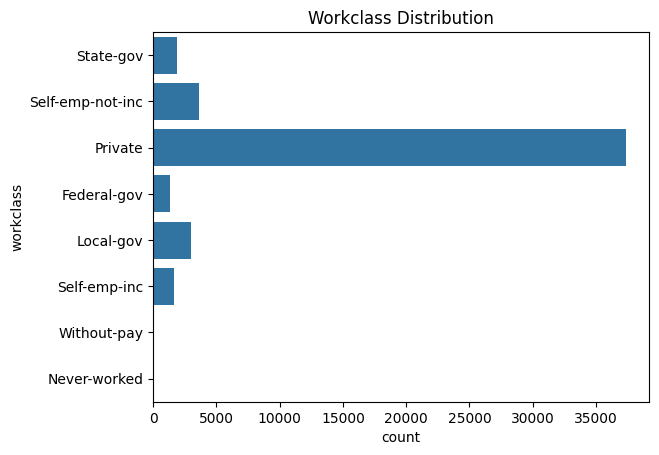

In [12]:
sns.countplot(data=df, y='workclass')
plt.title("Workclass Distribution")
plt.show()

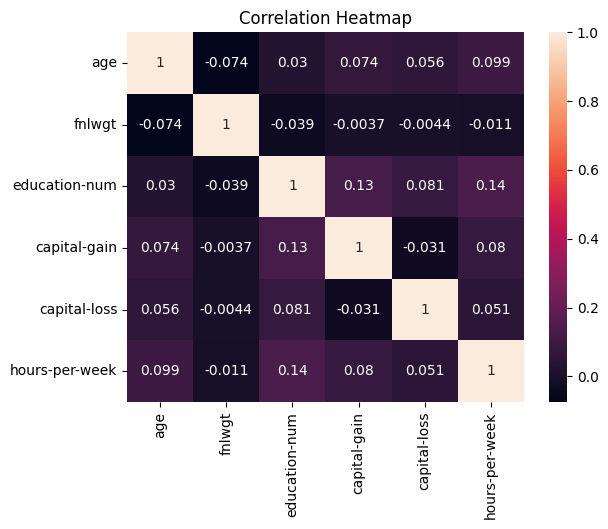

In [13]:
sns.heatmap(df[num_cols].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [14]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

print("Outliers treated.")

Outliers treated.


In [15]:
# Clean income values

df['income'] = df['income'].str.replace('.', '', regex=False)

# Remove income from clustering data
X = df.drop(columns=['income'])

# Convert categorical columns into numbers
X = pd.get_dummies(X, drop_first=True)

X.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39.0,77516.0,13.0,0,0,40.0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50.0,83311.0,13.0,0,0,32.5,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,38.0,215646.0,9.0,0,0,40.0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,53.0,234721.0,7.0,0,0,40.0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,28.0,338409.0,13.0,0,0,40.0,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [16]:
print("Shape after encoding:", X.shape)

Shape after encoding: (48842, 97)


In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling completed.")

Scaling completed.


In [18]:
#kmeans elbow method
wcss = []

for i in range(1, 11):
    km_obj = KMeans(
        n_clusters=i,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=0
    )

    km_obj.fit(X_scaled)

    wcss.append(km_obj.inertia_)

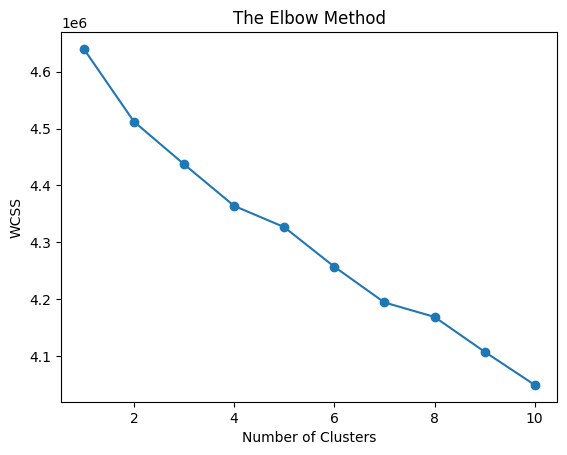

In [19]:
plt.plot(range(1, 11), wcss, marker='o')

plt.title("The Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [20]:
#Silhouette Score
for i in range(2, 8):

    km_obj = KMeans(
        n_clusters=i,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=0
    )

    labels = km_obj.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(i, "clusters -", round(score, 4))

2 clusters - 0.0512
3 clusters - 0.0447
4 clusters - 0.0378
5 clusters - 0.0494
6 clusters - 0.0343
7 clusters - 0.0309


In [21]:
#Final K-Means
k = 4

km_obj1 = KMeans(
    n_clusters=k,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=0
)

km_obj1.fit(X_scaled)

kmeans_cluster_labels = km_obj1.labels_

df['kmeans_cluster'] = kmeans_cluster_labels

df['kmeans_cluster'].value_counts().sort_index()

,count
kmeans_cluster,
0,30
1,3941
2,23679
3,21192


In [22]:
#PCA Visualize K-Means Clusters
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

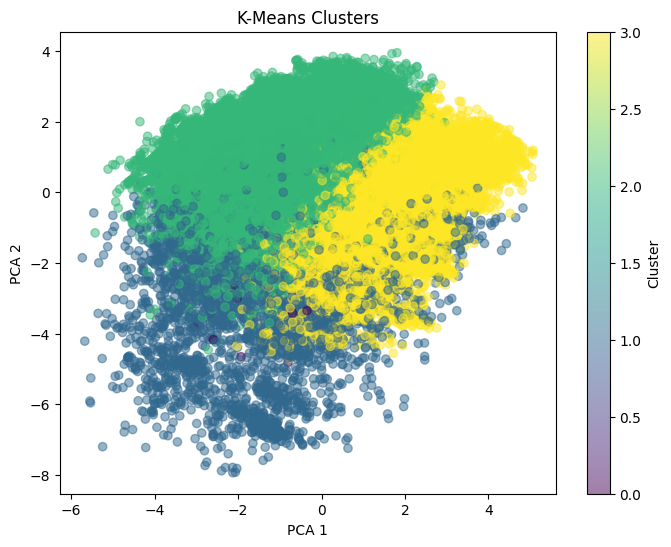

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_cluster_labels,
    cmap='viridis',
    alpha=0.5
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters")
plt.colorbar(label="Cluster")

plt.show()

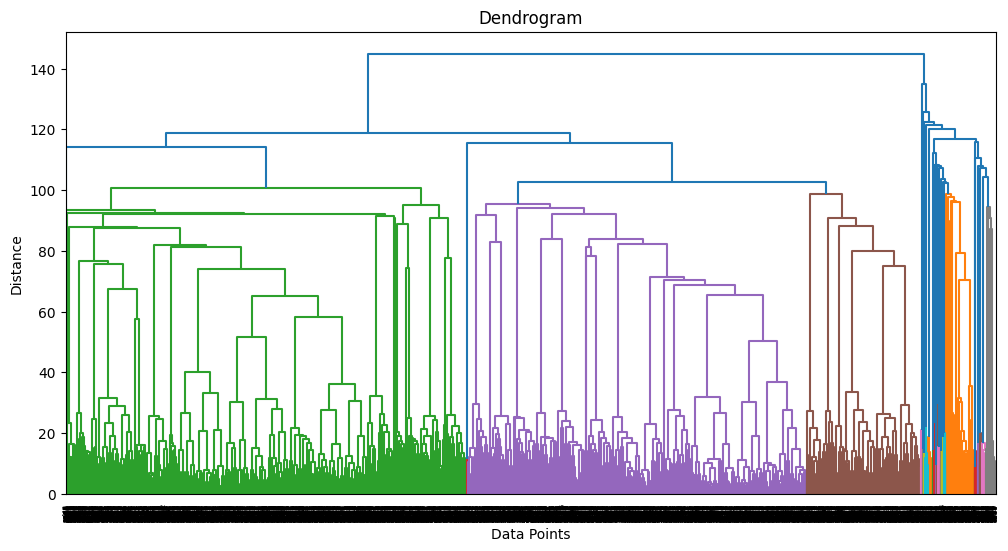

In [24]:
#Agglomerative Clustering
from scipy.cluster.hierarchy import linkage, dendrogram

# Use a sample because the dataset is large
sample = X_scaled[:5000]

mergings = linkage(sample, method='ward')

plt.figure(figsize=(12, 6))

dendrogram(mergings)

plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

In [25]:
ac_obj = AgglomerativeClustering(
    n_clusters=k,
    metric='euclidean',
    linkage='ward'
)

ac_clusters = ac_obj.fit_predict(sample)

print("Agglomerative clustering completed.")

Agglomerative clustering completed.


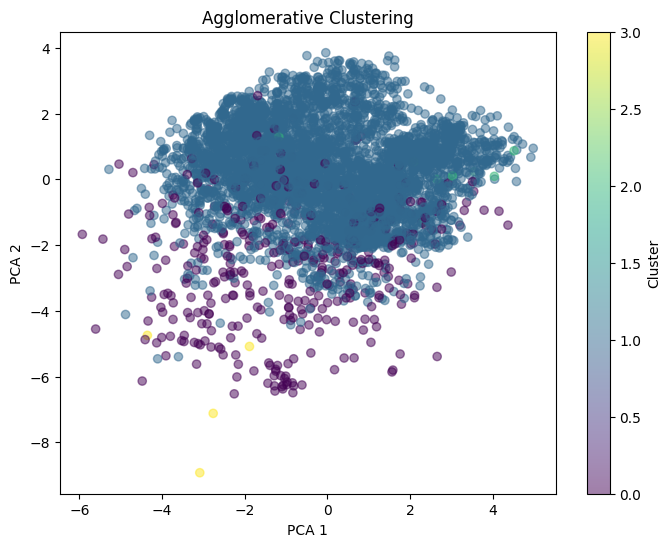

In [26]:
pca_sample = PCA(n_components=2)

sample_pca = pca_sample.fit_transform(sample)

plt.figure(figsize=(8, 6))

plt.scatter(
    sample_pca[:, 0],
    sample_pca[:, 1],
    c=ac_clusters,
    cmap='viridis',
    alpha=0.5
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Agglomerative Clustering")
plt.colorbar(label="Cluster")

plt.show()

In [27]:
print("Agglomerative Silhouette Score:",
      round(silhouette_score(sample, ac_clusters), 4))

Agglomerative Silhouette Score: 0.4977


In [28]:
#Cluster Profiling
df.groupby('kmeans_cluster')[num_cols].mean().round(2)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
kmeans_cluster,,,,,,
0,34.17,212912.10,10.62,0.0,0.0,40.02
1,38.12,210942.15,9.26,0.0,0.0,40.71
2,34.26,187596.62,9.95,0.0,0.0,39.61
3,43.39,181315.79,10.48,0.0,0.0,42.91


In [29]:
for cluster in sorted(df['kmeans_cluster'].unique()):

    temp = df[df['kmeans_cluster'] == cluster]

    print("\nCluster:", cluster)
    print("Average age:", round(temp['age'].mean(), 2))
    print("Average hours:", round(temp['hours-per-week'].mean(), 2))
    print("Education:", temp['education'].mode()[0])
    print("Workclass:", temp['workclass'].mode()[0])
    print("Occupation:", temp['occupation'].mode()[0])
    print("Marital status:", temp['marital-status'].mode()[0])


Cluster: 0
Average age: 34.17
Average hours: 40.02
Education: HS-grad
Workclass: Private
Occupation: Prof-specialty
Marital status: Married-civ-spouse

Cluster: 1
Average age: 38.12
Average hours: 40.71
Education: HS-grad
Workclass: Private
Occupation: Prof-specialty
Marital status: Married-civ-spouse

Cluster: 2
Average age: 34.26
Average hours: 39.61
Education: HS-grad
Workclass: Private
Occupation: Prof-specialty
Marital status: Never-married

Cluster: 3
Average age: 43.39
Average hours: 42.91
Education: HS-grad
Workclass: Private
Occupation: Prof-specialty
Marital status: Married-civ-spouse


In [30]:
#Compare Clusters with Income

income_cluster = pd.crosstab(
    df['kmeans_cluster'],
    df['income'],
    normalize='index'
).round(2)

income_cluster

income,<=50K,>50K
kmeans_cluster,,
0,0.73,0.27
1,0.82,0.18
2,0.94,0.06
3,0.55,0.45


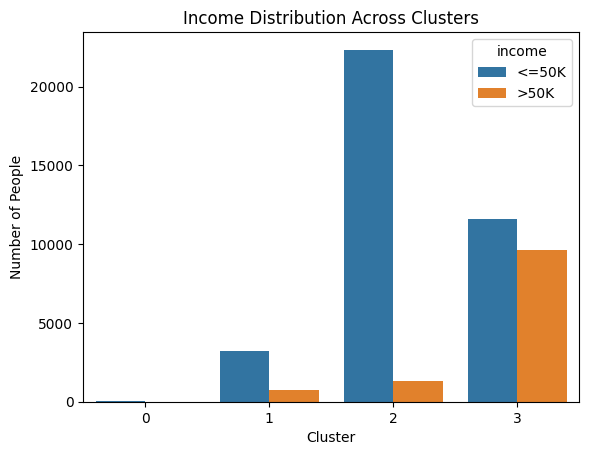

In [31]:
sns.countplot(
    data=df,
    x='kmeans_cluster',
    hue='income'
)

plt.title("Income Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of People")

plt.show()